In [15]:
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
import time
from pathlib import Path

`interpolate_case_griddata`
Interpolates scattered spatial data $(s, \theta, \text{field})$ onto a regular, periodic grid.

Uses `scipy.interpolate.griddata` with linear interpolation. It handles circumferential ($\theta$) periodicity by augmenting the data with shifted copies before interpolation, which prevents boundary artifacts at $\theta = 0$ and $2\pi$. Any NaN values resulting from points outside the convex hull are filled using nearest-neighbor interpolation.

**Parameters**
* **`s_norm`**: 1D array of shape $(N,)$ containing normalized arc lengths $s \in [0, 1]$.
* **`theta`**: 1D array of shape $(N,)$ containing circumferential angles $\theta \in [0, 2\pi]$.
* **`field_values`**: 1D array of shape $(N,)$ containing the scalar field to interpolate.
* **`n_s`**: Target grid resolution along the arc length ($s$) direction.
* **`n_theta`**: Target grid resolution along the circumferential ($\theta$) direction.
* **`s_range`**: Tuple $(s_{min}, s_{max})$ defining the bounds for the arc length domain. Default is `(0, 1)`.
* **`periodic_buffer`**: The margin (in radians) used to pad the angular domain for periodic augmentation. Default is `0.3`.

**Returns**
* **`field_grid`**: 2D array of shape $(n_s, n_\theta)$ containing the interpolated field.
* **`s_grid`**: 1D array of shape $(n_s,)$ containing the generated spatial grid coordinates.
* **`theta_grid`**: 1D array of shape $(n_\theta,)$ containing the generated angular grid coordinates.

In [2]:
def interpolate_case_griddata(s_norm, theta, field_values, n_s, n_t, s_range=(0, 1), periodic_buffer=0.3):
    s_grid = np.linspace(s_range[0], s_range[1], n_s)
    t_grid = np.linspace(0, 2*np.pi, n_t, endpoint=False)

    S_mesh, T_mesh = np.meshgrid(s_grid, t_grid, indexing='ij')
    query_pts = np.column_stack([S_mesh.ravel(), T_mesh.ravel()])

    s_aug = np.concatenate([s_norm, s_norm, s_norm])
    t_aug = np.concatenate([theta, theta - 2*np.pi, theta + 2*np.pi])
    val_aug = np.concatenate([field_values, field_values, field_values])

    mask = (t_aug >= -periodic_buffer) & (t_aug <= periodic_buffer + 2*np.pi)
    src_pts = np.column_stack([s_aug[mask], t_aug[mask]])

    field_flat = griddata(
        src_pts, val_aug[mask], query_pts, method='linear', fill_value=np.nan
    )

    if np.isnan(field_flat).any():
        nn_flat = griddata(
            src_pts, val_aug[mask], query_pts, method='nearest'
        )
        field_flat = np.where(np.isnan(field_flat), nn_flat, field_flat)

    field_grid = field_flat.reshape(n_s, n_t)

    return field_grid, s_grid, t_grid

`build_snapshot_matrix_at_resolution`
Constructs a snapshot matrix $X$ for a subset of geometric cases.

This function processes a batch of cases by mapping their scattered field data onto a uniform, high-resolution grid and flattening the results into column vectors. It is primarily used for resolution convergence testing rather than processing the full dataset.

**Parameters**
* **`case_subset`**: A list containing case dictionaries. Each dictionary must have:
  * `s`: array of raw arc lengths.
  * `theta`: array of circumferential angles.
  * `params`: list where the main parameters of the simulation have been defined $[d_p, \rho_p, U, R/d]$.
  * `angle` *(optional)*: array of impact angles.
  * `velocity` *(optional)*: array of velocities.
* **`n_s`**: Target grid resolution along the arc length ($s$) direction.
* **`n_theta`**: Target grid resolution along the circumferential ($\theta$) direction.
* **`s_bounds_per_geo`**: A dictionary mapping from the geometry identifier ($r_d$) to a tuple of its valid arc length bounds: `{rd: (s_min, s_max)}`.
* **`field_key`**: `{'angle', 'velocity_norm'}`, optional. Specifies which field to extract. If `'velocity_norm'`, the raw velocity $v$ is normalized by the reference velocity ($v/U$). Default is `'angle'`.

**Returns**
* **`X`**: A 2D snapshot matrix of shape $(M, N)$, where $M = n_s \times n_\theta$ (flattened grid size) and $N$ is the number of cases. Each column represents a single interpolated case.

In [3]:
def build_snapshot_matrix_at_resolution(case_subset, n_s, n_t, s_bounds_per_geo, field_key='angle'):
    M = n_s * n_t
    N = len(case_subset)
    X = np.zeros((M, N))

    for i, case in enumerate(case_subset):
        rd = case['params'][3]
        s_min, s_max = s_bounds_per_geo[rd]
        s_norm = np.clip((case['s']-s_min)/(s_max-s_min), 0, 1)
        theta = np.clip(case['theta'], 0, 2*np.pi)

        if field_key == 'velocity_norm':
            vals = case['velocity']/case['params'][2]
        else:
            vals = case[field_key]

        field, _, _ = interpolate_case_griddata(s_norm,  theta, vals, n_s, n_t)

        X[:, i] = field.ravel()

    return X

In [4]:
def run_pod(X, energy_threshold = 0.99):
    X_mean = X.mean(axis=1, keepdims=True)
    X_prime = X - X_mean
    U, s, Vt = np.linalg.svd(X_prime, full_matrices=False)

    energy = s**2/np.sum(s**2)
    cum_energy = np.cumsum(energy)
    r_star = np.searchsorted(cum_energy, energy_threshold) + 1

    return {
        'U':U, 's':s, 'Vt':Vt, 
        'energy':energy, 'cum_energy':cum_energy, 
        'r_star':r_star, 'X_mean': X_mean
    }

In [5]:
def energy_spectrum_convergence(pod_results_by_resolution, n_modes_compare=10):
    resolutions = sorted(pod_results_by_resolution.keys(), key=lambda r:r[0]*r[1])
    energy_matrix = np.array([
        pod_results_by_resolution[r]['energy'][:n_modes_compare]
        for r in resolutions
    ])

    rel_change = np.full(len(resolutions), np.nan)

    for i in range(0, len(resolutions)):
        diff = np.abs(energy_matrix[i] - energy_matrix[i-1])
        rel_change[i] = (diff/(energy_matrix[i-1] + 1e-10)).mean()

    print("Energy spectrum converged")
    print(f"{'Resolution':^15} {'M':^8} {'r* (99%)':^10} "
          f"{'Mode1 E%':^10} {'Δ from prev':^12}")
    print('-'*60)

    for i, r in enumerate(resolutions):
        M = r[0] * r[1]
        r_star = pod_results_by_resolution[r]['r_star']
        e1 = pod_results_by_resolution[r]['energy'][0] * 100
        change = rel_change[i] * 100
        flag = 'converged' if (i>0 and rel_change[i] < 0.02) else ''
        print(f"  {r[0]}×{r[1]:<10} {M:^8} {r_star:^10} "
              f"{e1:^10.2f} {change:^11.2f}%  {flag}")
        
    return resolutions, rel_change

In [6]:
def mode_shape_correlation(pod_results_by_resolution, n_modes_compare=4):
    resolutions = sorted(pod_results_by_resolution.keys(), key=lambda r: r[0] * r[1])
    ref_res = resolutions[-1]
    ref_ns, ref_nt = ref_res
    ref_modes = pod_results_by_resolution[ref_res]['U']

    print(f"\nMode shape correlation vs reference ({ref_ns}x{ref_nt}):")
    print(f"{'Resolution':^15} " + " ".join([f'{f"Mode{k+1}":^10}' for k in range(n_modes_compare)]))
    print("-"*70)

    correlations = np.zeros((len(resolutions), n_modes_compare))

    from scipy.ndimage import zoom

    for i, res in enumerate(resolutions):
        ns, nt = res
        modes = pod_results_by_resolution[res]['U']

        for k in range(min(n_modes_compare, modes.shape[1])):
            mode_k = modes[:, k].reshape(ns, nt)

            if (ns, nt) == (ref_ns, ref_nt):
                mode_k_upsampled = mode_k
            else:
                zoom_factors = (ref_ns / ns, ref_nt / nt)
                mode_k_upsampled = zoom(mode_k, zoom_factors, order=1)

            v1 = mode_k_upsampled.ravel()
            v2 = ref_modes[:, k]

            corr = np.abs(np.dot(v1, v2) /
                          (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10))
            correlations[i, k] = corr

        row_str = f"  {ns}x{nt:<10} "
        row_str += " ".join([f'{correlations[i,k]:^10.4f}' for k in range(n_modes_compare)])
        print(row_str)

    return resolutions, correlations

In [25]:
def reconstruction_error_convergence(case_subset, pod_results_by_resolution,
                                     s_bounds_per_geo, field_key='angle'):
    resolutions = sorted(pod_results_by_resolution.keys(), key=lambda r: r[0]*r[1])
    results = {}

    print("\nReconstruction error vs preprocessed points:")
    print(f"{'Resolution':^15} {'r*':^6} {'Mean err':^12} {'Max err':^12}")
    print("-"*55)

    from scipy.interpolate import RegularGridInterpolator

    for res in resolutions:
        ns, nt = res
        pod = pod_results_by_resolution[res]
        r_star = pod['r_star']
        errors = []

        for i, case in enumerate(case_subset):
            rd = case['params'][3]
            s_min, s_max = s_bounds_per_geo[rd]

            s_norm = np.clip((case['s'] - s_min) / (s_max - s_min), 0, 1)
            theta = np.mod(case['theta'], 2*np.pi)

            if field_key == 'velocity_norm':
                true_vals = case['velocity'] / case['params'][2]
            else:
                true_vals = case[field_key]

            coeffs = pod['s'][:r_star] * pod['Vt'][:r_star, i]
            field_recon = (
                pod['X_mean'].ravel() +
                pod['U'][:, :r_star] @ coeffs
            ).reshape(ns, nt)

            s_grid = np.linspace(0, 1, ns)
            t_grid = np.linspace(0, 2*np.pi, nt, endpoint=False)

            t_grid_ext = np.concatenate([t_grid, [2*np.pi]])
            field_ext = np.concatenate([field_recon, field_recon[:, :1]], axis=1)

            interp = RegularGridInterpolator(
                (s_grid, t_grid_ext),
                field_ext,
                bounds_error=False,
                fill_value=None
            )

            pred_vals = interp(np.column_stack([s_norm, theta]))

            valid = np.isfinite(pred_vals) & np.isfinite(true_vals)
            denom = np.linalg.norm(true_vals[valid])

            if valid.sum() == 0 or denom == 0:
                errors.append(np.nan)
            else:
                err = np.linalg.norm(pred_vals[valid] - true_vals[valid]) / denom
                errors.append(err)

        errors = np.array(errors)
        results[res] = errors

        print(f"  {ns}x{nt:<10} {r_star:^6} "
              f"{np.nanmean(errors)*100:^11.3f}% {np.nanmax(errors)*100:^11.3f}%")

    return results

In [8]:
def find_optimal_pod_resolution(all_cases, params, s_bounds_per_geo,
                                n_subset=60, 
                                candidate_resolutions=None,
                                convergence_threshold=0.02, 
                                field_key='angle'):
    if candidate_resolutions is None:
        candidate_resolutions = [
            (100, 120), 
            (200, 120), 
            (300, 120), 
            (400, 120), 
            (500, 120), 
            (800, 120), 
            (1000, 120), 
            (1200, 120)
        ]

    rng = np.random.default_rng(42)
    subset_idx = []

    for rd in [1.5, 2.0, 5.0]:
        idx_rd = np.where(params[:, 3] == rd)[0]
        n_per_rd = n_subset // 3
        chosen = rng.choice(idx_rd, size=n_per_rd, replace=False)
        subset_idx.extend(chosen)

    subset_idx = np.array(subset_idx)
    case_subset = [all_cases[i] for i in subset_idx]
    print(f"Using {len(case_subset)} representative cases for "
        f"resolution search (stratified across R/D)\n")
    

    pod_results = {}
    timing = {}

    for ns, nt in candidate_resolutions:
        t0 = time.time()
        X = build_snapshot_matrix_at_resolution(case_subset, ns, nt, s_bounds_per_geo, field_key=field_key)
        pod_results[(ns, nt)] = run_pod(X)
        timing[(ns, nt)] = time.time() - t0
        print(f"  {ns}×{nt}: done in {timing[(ns,nt)]:.1f}s, "
            f"r*={pod_results[(ns,nt)]['r_star']}")
        
    print("\n" + "="*65)
    print("METRIC 1: ENERGY SPECTRUM CONVERGENCE")
    print("="*65)
    res_list, energy_change = energy_spectrum_convergence(pod_results)

    print("\n" + "="*65)
    print("METRIC 2: MODE SHAPE CORRELATION")
    print("="*65)
    res_list2, mode_corr = mode_shape_correlation(pod_results)

    print("\n" + "="*65)
    print("METRIC 3: RECONSTRUCTION ERROR vs SCATTERED DATA")
    print("="*65)
    recon_errors = reconstruction_error_convergence(
        case_subset, pod_results, s_bounds_per_geo
    )

    print("\n" + "="*65)
    print("DECISION")
    print("="*65)

    resolutions_sorted = sorted(candidate_resolutions, key=lambda r: r[0]*r[1])
    chosen = None

    for i, res in enumerate(resolutions_sorted):
        if i == 0:
            continue  # need a previous point to compare against

        energy_ok = energy_change[i] < convergence_threshold
        mode_ok   = mode_corr[i].mean() > 0.97   # high similarity to finest
        err       = recon_errors[res].mean()
        err_prev  = recon_errors[resolutions_sorted[i-1]].mean()
        err_ok    = abs(err - err_prev) / err_prev < 0.05  # < 5% relative change

        print(f"  {res[0]}×{res[1]}: energy_ok={energy_ok}, "
              f"mode_ok={mode_ok}, err_ok={err_ok}")

        if energy_ok and mode_ok and err_ok and chosen is None:
            chosen = res

    if chosen is None:
        chosen = resolutions_sorted[-1]
        print(f"\n No resolution fully converged — using finest tested: "
              f"{chosen}")
    else:
        print(f"\n→ OPTIMAL RESOLUTION: {chosen[0]} × {chosen[1]} "
              f"= {chosen[0]*chosen[1]:,} points")
        print(f"  This is the coarsest grid where:")
        print(f"    - Energy spectrum changed by < {convergence_threshold*100}%")
        print(f"    - Mode shapes correlate > 0.97 with finest tested grid")
        print(f"    - Reconstruction error changed by < 5%")

    return chosen, pod_results, recon_errors

In [9]:
def plot_resolution_convergence(pod_results, mode_corr, recon_errors,
                                  candidate_resolutions, chosen_resolution):
    """
    Publication-quality figure for the grid convergence study.
    This goes directly in your paper as justification for grid choice.
    """
    resolutions = sorted(candidate_resolutions, key=lambda r: r[0]*r[1])
    M_values    = [r[0]*r[1] for r in resolutions]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # ── Panel 1: r* and Mode 1 energy vs M ────────────────────────────────────
    ax = axes[0]
    r_stars   = [pod_results[r]['r_star'] for r in resolutions]
    e1_vals   = [pod_results[r]['energy'][0]*100 for r in resolutions]

    ax2 = ax.twinx()
    l1 = ax.plot(M_values, r_stars, 'o-', color='#2196F3',
                  markersize=8, linewidth=2, label='r* (99% energy)')
    l2 = ax2.plot(M_values, e1_vals, 's-', color='#FF5722',
                   markersize=8, linewidth=2, label='Mode 1 energy (%)')

    ax.set_xlabel('Grid points M', fontsize=12)
    ax.set_ylabel('r* (modes for 99%)', color='#2196F3', fontsize=12)
    ax2.set_ylabel('Mode 1 energy (%)', color='#FF5722', fontsize=12)
    ax.set_xscale('log')
    ax.set_title('Energy Spectrum Convergence', fontsize=13)
    ax.axvline(chosen_resolution[0]*chosen_resolution[1],
               color='green', linestyle='--', linewidth=2,
               label='Chosen resolution')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: Mode shape correlation vs M ─────────────────────────────────
    ax = axes[1]
    for k in range(mode_corr.shape[1]):
        ax.plot(M_values, mode_corr[:, k], 'o-',
                 label=f'Mode {k+1}', markersize=6, linewidth=2)
    ax.axhline(0.97, color='black', linestyle=':',
               label='0.97 threshold')
    ax.axvline(chosen_resolution[0]*chosen_resolution[1],
               color='green', linestyle='--', linewidth=2)
    ax.set_xlabel('Grid points M', fontsize=12)
    ax.set_ylabel('Cosine similarity to finest grid', fontsize=12)
    ax.set_xscale('log')
    ax.set_title('Mode Shape Stability', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Panel 3: Reconstruction error vs M ───────────────────────────────────
    ax = axes[2]
    mean_errs = [recon_errors[r].mean()*100 for r in resolutions]
    max_errs  = [recon_errors[r].max()*100 for r in resolutions]

    ax.plot(M_values, mean_errs, 'o-', color='#4CAF50',
             markersize=8, linewidth=2, label='Mean error')
    ax.plot(M_values, max_errs, 's--', color='#F44336',
             markersize=6, linewidth=1.5, label='Max error')
    ax.axvline(chosen_resolution[0]*chosen_resolution[1],
               color='green', linestyle='--', linewidth=2,
               label='Chosen resolution')
    ax.set_xlabel('Grid points M', fontsize=12)
    ax.set_ylabel('Reconstruction error (%)', fontsize=12)
    ax.set_xscale('log')
    ax.set_title('Reconstruction Error vs Scattered Data', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Grid Resolution Convergence Study for POD\n'
                  f'Chosen: {chosen_resolution[0]}×{chosen_resolution[1]} = '
                  f'{chosen_resolution[0]*chosen_resolution[1]:,} points',
                  fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_pod_resolution_convergence.pdf',
                bbox_inches='tight', dpi=300)
    plt.savefig('fig_pod_resolution_convergence.png',
                bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: fig_pod_resolution_convergence.pdf")

In [29]:
PARTICLE_SIZES_micro = [50, 100, 150, 200, 300, 500]
DENSITY = [2000, 5000, 10000, 15000, 30000]
VELOCITY = [5, 10, 15, 18, 20]
bend_ratio = [1.5, 2, 5]
PARTICLE_SIZES = np.array(PARTICLE_SIZES_micro) * 1e-6

all_cases = []
params = []
data_dir = Path("trimmed_data_csv")

for i, br in enumerate(bend_ratio):
    for j, U in enumerate(VELOCITY):
        for k, rho in enumerate(DENSITY):
            for l, dp in enumerate(PARTICLE_SIZES):
                path = data_dir / f"{i+1}{j+1}{k+1}{l+1}.csv"
                if not path.exists():
                    continue

                df = pd.read_csv(path)
                p = np.array([dp, rho, U, br], dtype=float)

                all_cases.append({
                    "case_id": path.stem,
                    "params": p,
                    "s": df["s_normalized"].to_numpy(float),
                    "theta": np.mod(df["theta"].to_numpy(float) + np.pi, 2*np.pi),
                    "angle": df["angle"].to_numpy(float),
                    "velocity": df["velocity"].to_numpy(float),
                    "oka-erosion-function": df["oka-erosion-function"].to_numpy(float),
                    "frequency": df["frequency"].to_numpy(float),
                })
                params.append(p)

params = np.vstack(params)
s_bounds_per_geo = {br: (0.0, 1.0) for br in bend_ratio}

print(len(all_cases), "cases loaded")

450 cases loaded


Using 60 representative cases for resolution search (stratified across R/D)

  300×120: done in 111.4s, r*=51
  400×120: done in 112.5s, r*=51
  500×120: done in 111.9s, r*=51
  800×120: done in 113.4s, r*=51
  1200×120: done in 116.3s, r*=51

METRIC 1: ENERGY SPECTRUM CONVERGENCE
Energy spectrum converged
  Resolution       M      r* (99%)   Mode1 E%  Δ from prev 
------------------------------------------------------------
  300×120         36000       51       53.13       0.50    %  
  400×120         48000       51       53.30       0.55    %  converged
  500×120         60000       51       53.28       0.41    %  converged
  800×120         96000       51       53.32       0.23    %  converged
  1200×120         144000      51       53.35       0.06    %  converged

METRIC 2: MODE SHAPE CORRELATION

Mode shape correlation vs reference (1200x120):
  Resolution      Mode1      Mode2      Mode3      Mode4   
----------------------------------------------------------------------
  300

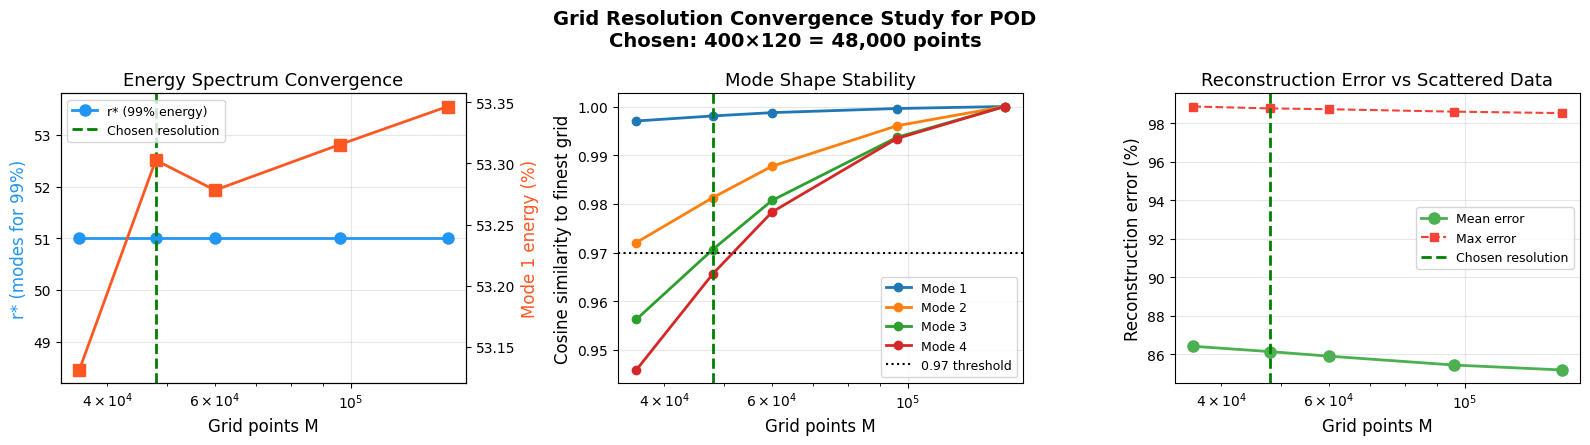

Saved: fig_pod_resolution_convergence.pdf


In [31]:
FIELD_KEY = "velocity_norm"   # or "angle", "velocity_norm", "frequency"

candidate_resolutions = candidate_resolutions = [
    # (100, 120), 
    # (200, 120), 
    (300, 120), 
    (400, 120), 
    (500, 120), 
    (800, 120), 
    # (1000, 120), 
    (1200, 120),
    # (2000, 240)
]

chosen_res, pod_results, recon_errors = find_optimal_pod_resolution(
    all_cases, params, s_bounds_per_geo,
    n_subset=60,
    candidate_resolutions=candidate_resolutions,
    convergence_threshold=0.1,
    field_key=FIELD_KEY,
)

_, mode_corr = mode_shape_correlation(pod_results)

plot_resolution_convergence(
    pod_results,
    mode_corr,
    recon_errors,
    candidate_resolutions,
    chosen_res
)

# X_full = build_snapshot_matrix_at_resolution(
#     all_cases,
#     chosen_res[0],
#     chosen_res[1],
#     s_bounds_per_geo,
#     field_key=FIELD_KEY
# )

# pod_full = run_pod(X_full)